In [33]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


In [ ]:
"""SOURCES/BACKGROUND Research

4.1
https://www.datacamp.com/tutorial/understanding-logistic-regression-python
https://stackoverflow.com/questions/47437893/how-to-calculate-logistic-regression-accuracy
https://www.datacamp.com/tutorial/k-nearest-neighbor-classification-scikit-learn
https://www.datacamp.com/tutorial/naive-bayes-scikit-learn 

4.2
https://stackoverflow.com/questions/22294241/plotting-a-decision-boundary-separating-2-classes-using-matplotlibs-pyplot

"""

In [6]:

file_path = "data/marriage.csv"
df = pd.read_csv(file_path, header=None)

df.head()


,0,1,2,3,4,5,6,7,8,9,...,45,46,47,48,49,50,51,52,53,54
0,1.560903,3.681587,3.450467,3.211998,-1.203045,0.597706,-0.970093,-0.750970,-0.511495,-0.133660,...,2.077401,1.184182,3.955069,2.608046,2.303629,1.721660,3.275018,1.761019,1.215237,1.0
1,4.153272,5.173858,4.100690,2.580173,3.305788,-1.505512,-0.029398,5.702657,2.230281,4.975496,...,3.467076,2.451984,3.504294,5.324240,4.480607,5.375248,2.270379,2.167944,2.191214,1.0
2,2.226241,1.575322,2.389117,2.725405,-0.304562,2.832803,1.787779,0.565755,1.328212,2.335353,...,1.200917,1.241794,2.207492,1.228034,0.870052,1.685040,2.341985,-0.444320,2.527452,1.0
3,3.553458,2.859042,2.928414,1.833241,1.271119,4.165213,2.078597,4.506175,2.521628,2.747315,...,3.196291,2.204824,3.664982,3.689508,2.577677,3.171884,2.164660,1.813024,1.376033,1.0
4,0.506547,1.419223,1.716153,1.319274,2.853840,0.047412,-0.016515,0.620795,1.202992,0.078347,...,1.806657,2.085539,2.012551,1.899477,1.510134,1.373350,2.551119,0.846321,-0.066858,1.0


In [27]:
# Load dataset
data = pd.read_csv("data/marriage.csv", header=None)
data.rename(columns={54: "y"}, inplace=True)

# Define X (features) and y (target)
X = data.iloc[:, 0:54]  # Columns 0-53 are predictors
y = data.iloc[:, 54]    # Column 54 is the target variable

# Split dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

logreg = LogisticRegression(random_state=16)
# fit the model with data
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)
score =accuracy_score(y_test,y_pred)
print("Accuracy of Log Reg:", score)


knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy of KNN:", accuracy)


model = GaussianNB()

# Model training
model.fit(X_train, y_train)

# Fix for single sample prediction
predicted = model.predict(X_test.iloc[[6]])  

# Compute accuracy and F1 score
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy of Naive Bayes:", accuracy)


Accuracy of Log Reg: 0.9705882352941176
Accuracy of KNN: 0.9705882352941176
Accuracy of Naive Bayes: 0.9705882352941176


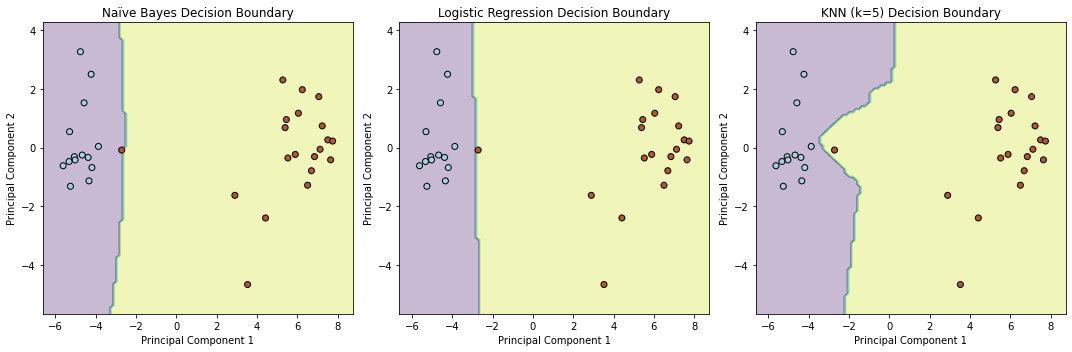

In [34]:

# Load dataset
data = pd.read_csv("data/marriage.csv", header=None)
data.rename(columns={54: "y"}, inplace=True)

# Define X (features) and y (target)
X = data.iloc[:, 0:54]  # Features (columns 0-53)
y = data.iloc[:, 54]    # Target variable (column 54)

# Standardize the features before PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Perform PCA to reduce to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Split dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

# Train classifiers
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

logreg_model = LogisticRegression(max_iter=1000)
logreg_model.fit(X_train, y_train)

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

# Function to plot decision boundaries
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k", cmap=plt.cm.Paired)
    plt.title(title)
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")

# Plot decision boundaries
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plot_decision_boundary(nb_model, X_test, y_test, "Naïve Bayes Decision Boundary")

plt.subplot(1, 3, 2)
plot_decision_boundary(logreg_model, X_test, y_test, "Logistic Regression Decision Boundary")

plt.subplot(1, 3, 3)
plot_decision_boundary(knn_model, X_test, y_test, "KNN (k=5) Decision Boundary")

plt.tight_layout()
plt.show()